In [1]:
num_particles = 100
run_time_days = 20
time_step_minutes = 20
out_put_step_hours = 6

#initial position
# -50.0 -49.08333206176758 -0.08333330601453781 1.1665860414505005
# -49.75, -48.33,-0.17,1.33
lon0 = -49.75
lon1 = -48.33
lat0 = 1.33
lat1 = -0.17

depth_min = 2 #todo: figure near-surface depths 
depth_max = 6

offset = 1
ref_date = "1993-01-01"
#reproducibility
rdm_seed = 23456

#paths
pathUVW= '/work/bk1450/b383184/Amazon/Mercator/data/variables_c'
# pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'
pathTS = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c"
Hgr = "/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc"
Zgr = "/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc"

In [2]:
import numpy as np

In [3]:
out_path = f'../data/tracks_{rdm_seed}/' #path to store the particle zarr

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
start_time

np.datetime64('1993-01-02')

## Particles from the Plume to the Atlantic

* Release particles from the plume every 5 days for 4 years (1993-1999)
* Release time 1993 to 2013
* Number of particles =  10_000
* Release depth = (0,10)
* Tracking salinity and temperature

In [4]:
from parcels import ParticleSet
from parcels import JITParticle
# from parcels import ScipyParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [5]:
np.random.seed(rdm_seed)

### Copernicus Data (C grid)

In [6]:
# ufiles = sorted(glob(f"{pathUVW}/U_1997.nc"))
# vfiles = sorted(glob(f"{pathUVW}/V_1997.nc"))
# wfiles = sorted(glob(f"{pathUVW}/W_1997.nc"))
# Tfiles = sorted(glob(f"{pathTS}/T_1997.nc"))
# Sfiles = sorted(glob(f"{pathTS}/S_1997.nc"))

ufiles = f"{pathUVW}/U_1993-01c.nc"
vfiles = f"{pathUVW}/V_1993-01c.nc"
wfiles = f"{pathUVW}/W_1993-01c.nc"
# Tfiles = f"{pathTS}/T_1993-01.nc"
# Sfiles = f"{pathTS}/S_1993-01.nc"

In [7]:
# print(len(ufiles))
# print(len(vfiles))
# print(len(wfiles))
# print(len(Tfiles))
# print(len(Sfiles))
ufiles

'/work/bk1450/b383184/Amazon/Mercator/data/variables_c/U_1993-01c.nc'

In [8]:
## define the fieldset
filenames = {
    "U": {
        "data":ufiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles,
    },
    
    "V": {
        "data": vfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles,
    },
    
    "W": {
        "data": wfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles,
    },
}

variables = {
    "U": "vozocrtx",
    "V": "vomecrty",
    "W": "vovecrtz",
}

interp_method = {
    "U":"cgrid_velocity",
    "V":"cgrid_velocity",
    "W":"cgrid_velocity",
}

# dimensions = {
#     "U": {"lon": "glamf", "lat": "gphif", "depth": "hdepw", "time": "time_counter"},
#     "V": {"lon": "glamf", "lat": "gphif", "depth": "hdepw", "time": "time_counter"},
#     "W": {"lon": "glamf", "lat": "gphif", "depth": "hdepw", "time": "time_counter"},
# }

dimensions = {
    "U": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "V": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "W": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames, 
    variables, 
    dimensions,
    interp_method = interp_method,
    # tracer_interp_method="cgrid_tracer",
    deferred_load=True,
    allow_time_extrapolation = False,
    gridindexingtype = "nemo",
)

In [9]:
fieldset.U

<Field>
    name            : 'U'
    grid            : CurvilinearZGrid(lon=array([[-94.96, -94.88, -94.79, ...,  9.79,  9.88,  9.96],
       [-94.96, -94.88, -94.79, ...,  9.79,  9.88,  9.96],
       [-94.96, -94.88, -94.79, ...,  9.79,  9.88,  9.96],
       ...,
       [-94.96, -94.88, -94.80, ...,  9.80,  9.89,  9.97],
       [-94.96, -94.88, -94.80, ...,  9.81,  9.89,  9.97],
       [-94.96, -94.88, -94.80, ...,  9.81,  9.89,  9.97]], shape=(499, 1260), dtype=float32), lat=array([[-9.91, -9.91, -9.91, ..., -9.91, -9.91, -9.91],
       [-9.83, -9.83, -9.83, ..., -9.83, -9.83, -9.83],
       [-9.74, -9.74, -9.74, ..., -9.74, -9.74, -9.74],
       ...,
       [ 29.80,  29.80,  29.80, ...,  29.84,  29.84,  29.84],
       [ 29.87,  29.87,  29.87, ...,  29.91,  29.91,  29.91],
       [ 29.94,  29.94,  29.94, ...,  29.98,  29.98,  29.98]], shape=(499, 1260), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=19

In [10]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [11]:
pset = ParticleSet(
    fieldset=fieldset,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 

out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [12]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [13]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks_23456/Parcels_run_23456_1993-01-02.zarr.
100%|██████████| 1728000.0/1728000.0 [03:53<00:00, 7397.67it/s] 


### Plotting

In [14]:
import xarray as xr

In [15]:
out_path = f'../data/tracks_{rdm_seed}/'
# out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 257kB
Dimensions:     (trajectory: 100, obs: 80)
Coordinates:
  * obs         (obs) int32 320B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    lat         (trajectory, obs) float64 64kB 0.8473 0.8594 ... 0.07641 0.07911
    lon         (trajectory, obs) float64 64kB -49.29 -49.31 ... -48.82 -48.83
    time        (trajectory, obs) datetime64[ns] 64kB 1993-01-02 ... 1993-01-...
    z           (trajectory, obs) float64 64kB 3.012 2.987 2.965 ... 1.437 1.37
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

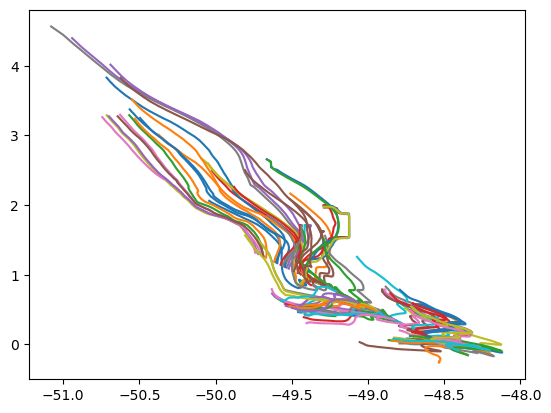

In [16]:
import matplotlib.pyplot as plt
for ii in range(100):
    plt.plot(ds_traj.isel(trajectory=ii).lon.data, ds_traj.isel(trajectory=ii).lat.data,marker='.',markersize=0.1)
# ds_traj.isel(trajectory=10)

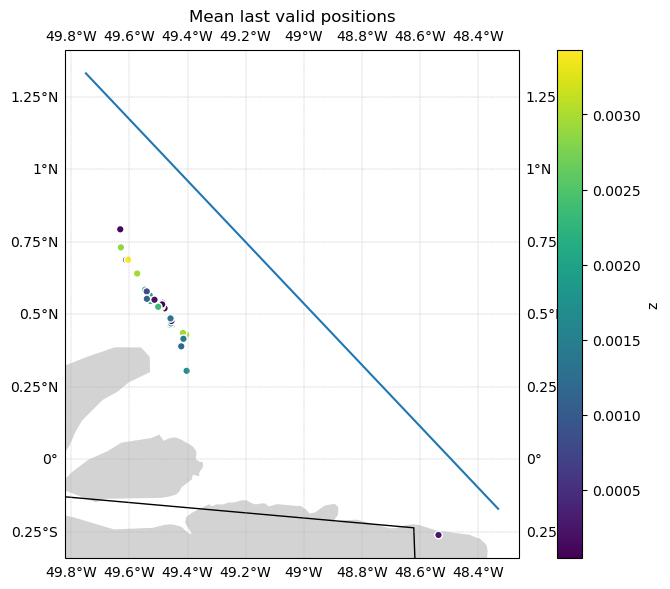

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

last_valid = ds_traj.lat.notnull().astype(int).diff('obs', label='lower') == -1
ends = ds_traj.where(last_valid).mean('obs').compute()

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.3)

ends.plot.scatter(
    x='lon',
    y='lat',
    hue='z' if 'z' in ends else None,
    cmap='viridis',
    s=30,
    ax=ax,
    transform=ccrs.PlateCarree()
)

ax.plot([lon0, lon1], [lat0, lat1])

plt.title('Mean last valid positions')
plt.tight_layout()
plt.show()

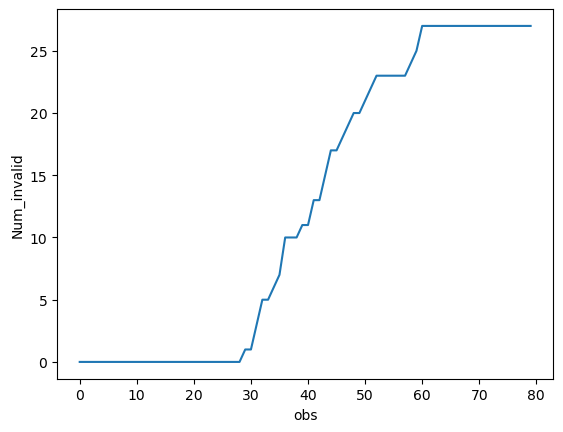

In [18]:
import matplotlib.pyplot as plt
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

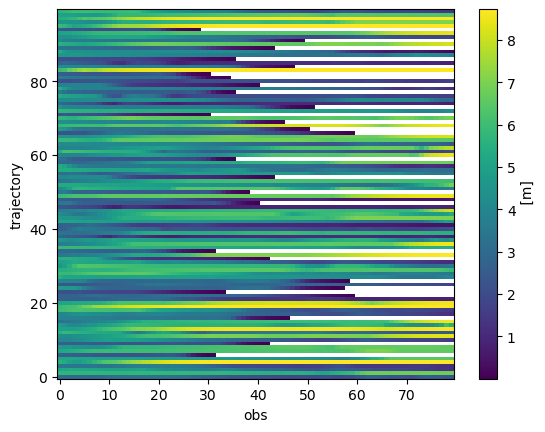

In [19]:
ds_traj.z.plot()
plt.show()